In [7]:
# =========================================================
# MOUNT GOOGLE DRIVE
# =========================================================

from google.colab import drive

drive.mount('/content/drive')

print("✅ Google Drive mounted.")

Mounted at /content/drive


In [8]:
# =========================================================
# INSTALL REQUIRED LIBRARIES
# =========================================================

!pip install -q timm
!pip install -q seaborn

In [9]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import os
import json
import random
import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import timm

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

import albumentations as A
from albumentations.pytorch import ToTensorV2

print("✅ Libraries imported.")

✅ Libraries imported.


In [10]:
# =========================================================
# CONFIG
# =========================================================

PROJECT_ROOT = "/content/drive/MyDrive/PersonalFashionStylistV2"

CONFIG = {

    "test_csv": os.path.join(
        PROJECT_ROOT,
        "datasets/metadata/test.csv"
    ),

    "checkpoint_path": os.path.join(
        PROJECT_ROOT,
        "models/checkpoints/best_convnext_tiny.pth"
    ),

    "img_size": 224,

    "batch_size": 32
}

print("✅ Config initialized.")

✅ Config initialized.


In [11]:
# =========================================================
# DEVICE
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("✅ Device:", device)

✅ Device: cuda


In [12]:
# =========================================================
# CHECK LABEL MAP DIRECTORY
# =========================================================

mapping_dir = "/content/drive/MyDrive/PersonalFashionStylistV2/models/label_maps"

print("✅ Files inside label_maps:\n")

print(os.listdir(mapping_dir))

✅ Files inside label_maps:

['label_map.json', 'idx_to_class.json', 'class_to_idx.json']


In [13]:
# =========================================================
# LOAD LABEL MAPPINGS
# =========================================================

mapping_dir = os.path.join(
    PROJECT_ROOT,
    "models",
    "label_maps"
)

with open(os.path.join(mapping_dir, "class_to_idx.json")) as f:
    CLASS_TO_IDX = json.load(f)

with open(os.path.join(mapping_dir, "idx_to_class.json")) as f:
    IDX_TO_CLASS = json.load(f)

NUM_CLASSES = len(CLASS_TO_IDX)

print("✅ Label mappings loaded.")

print(CLASS_TO_IDX)

✅ Label mappings loaded.
{'hoodie': 0, 'jeans': 1, 'pants': 2, 'shirt': 3, 'tshirt': 4}


In [14]:
# =========================================================
# LOAD TEST DATAFRAME
# =========================================================

test_df = pd.read_csv(CONFIG["test_csv"])

print("✅ Test dataframe loaded.")

print("Test Images:", len(test_df))

✅ Test dataframe loaded.
Test Images: 1294


In [15]:
# =========================================================
# COPY DATASET TO LOCAL SSD
# =========================================================

import shutil

drive_dataset_dir = os.path.join(
    PROJECT_ROOT,
    "datasets",
    "ecommerce",
    "dataset_clean"
)

local_dataset_dir = "/content/dataset_clean"

if not os.path.exists(local_dataset_dir):

    print("🚀 Copying dataset...")

    shutil.copytree(
        drive_dataset_dir,
        local_dataset_dir
    )

print("✅ Local dataset ready.")

🚀 Copying dataset...
✅ Local dataset ready.


In [16]:
# =========================================================
# REPLACE DRIVE PATHS
# =========================================================

def replace_drive_path(path):

    return path.replace(
        os.path.join(
            PROJECT_ROOT,
            "datasets",
            "ecommerce",
            "dataset_clean"
        ),
        "/content/dataset_clean"
    )

test_df["image_path"] = test_df["image_path"].apply(
    replace_drive_path
)

print("✅ Paths updated.")

✅ Paths updated.


In [17]:
# =========================================================
# TEST TRANSFORMS
# =========================================================

test_transforms = A.Compose([

    A.Resize(
        CONFIG["img_size"],
        CONFIG["img_size"]
    ),

    A.Normalize(),

    ToTensorV2()
])

print("✅ Test transforms ready.")

✅ Test transforms ready.


In [18]:
# =========================================================
# TEST DATASET CLASS
# =========================================================

class FashionDataset(Dataset):

    def __init__(self, dataframe, transforms=None):

        self.dataframe = dataframe.reset_index(drop=True)

        self.transforms = transforms

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = row["image_path"]

        label_name = row["label"]

        label = CLASS_TO_IDX[label_name]

        image = Image.open(image_path).convert("RGB")

        image = np.array(image)

        if self.transforms:

            transformed = self.transforms(image=image)

            image = transformed["image"]

        return image, label

In [19]:
# =========================================================
# CREATE TEST DATASET + LOADER
# =========================================================

test_dataset = FashionDataset(
    test_df,
    transforms=test_transforms
)

test_loader = DataLoader(

    test_dataset,

    batch_size=CONFIG["batch_size"],

    shuffle=False,

    num_workers=2,

    pin_memory=True
)

print("✅ Test DataLoader ready.")

✅ Test DataLoader ready.


In [20]:
# =========================================================
# LOAD CONVNEXT MODEL
# =========================================================

model = timm.create_model(

    "convnext_tiny",

    pretrained=False,

    num_classes=NUM_CLASSES
)

model.load_state_dict(

    torch.load(
        CONFIG["checkpoint_path"],
        map_location=device
    )
)

model = model.to(device)

model.eval()

print("✅ Trained model loaded successfully.")

✅ Trained model loaded successfully.


In [21]:
# =========================================================
# RUN TEST PREDICTIONS
# =========================================================

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print("✅ Predictions completed.")

✅ Predictions completed.


In [22]:
# =========================================================
# TEST ACCURACY
# =========================================================

test_acc = accuracy_score(
    all_labels,
    all_preds
)

print(f"🔥 Test Accuracy: {test_acc:.4f}")

🔥 Test Accuracy: 0.9606


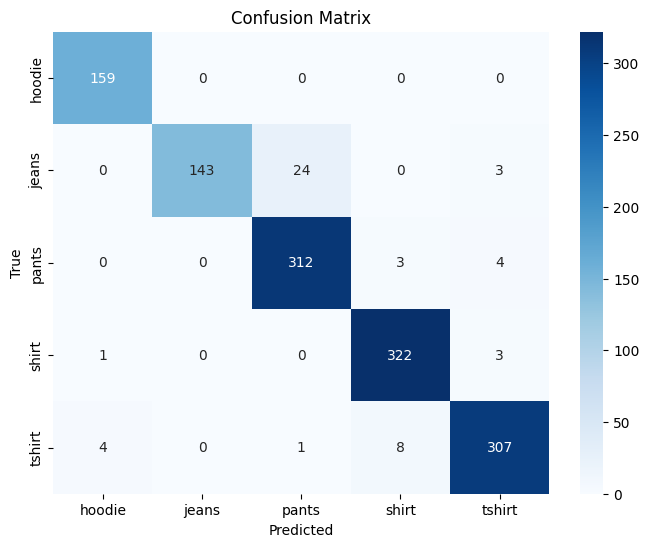

In [23]:
# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

class_names = list(CLASS_TO_IDX.keys())

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("Confusion Matrix")

plt.show()

In [24]:
# =========================================================
# CLASSIFICATION REPORT
# =========================================================

target_names = list(CLASS_TO_IDX.keys())

report = classification_report(

    all_labels,

    all_preds,

    target_names=target_names
)

print(report)

              precision    recall  f1-score   support

      hoodie       0.97      1.00      0.98       159
       jeans       1.00      0.84      0.91       170
       pants       0.93      0.98      0.95       319
       shirt       0.97      0.99      0.98       326
      tshirt       0.97      0.96      0.96       320

    accuracy                           0.96      1294
   macro avg       0.97      0.95      0.96      1294
weighted avg       0.96      0.96      0.96      1294



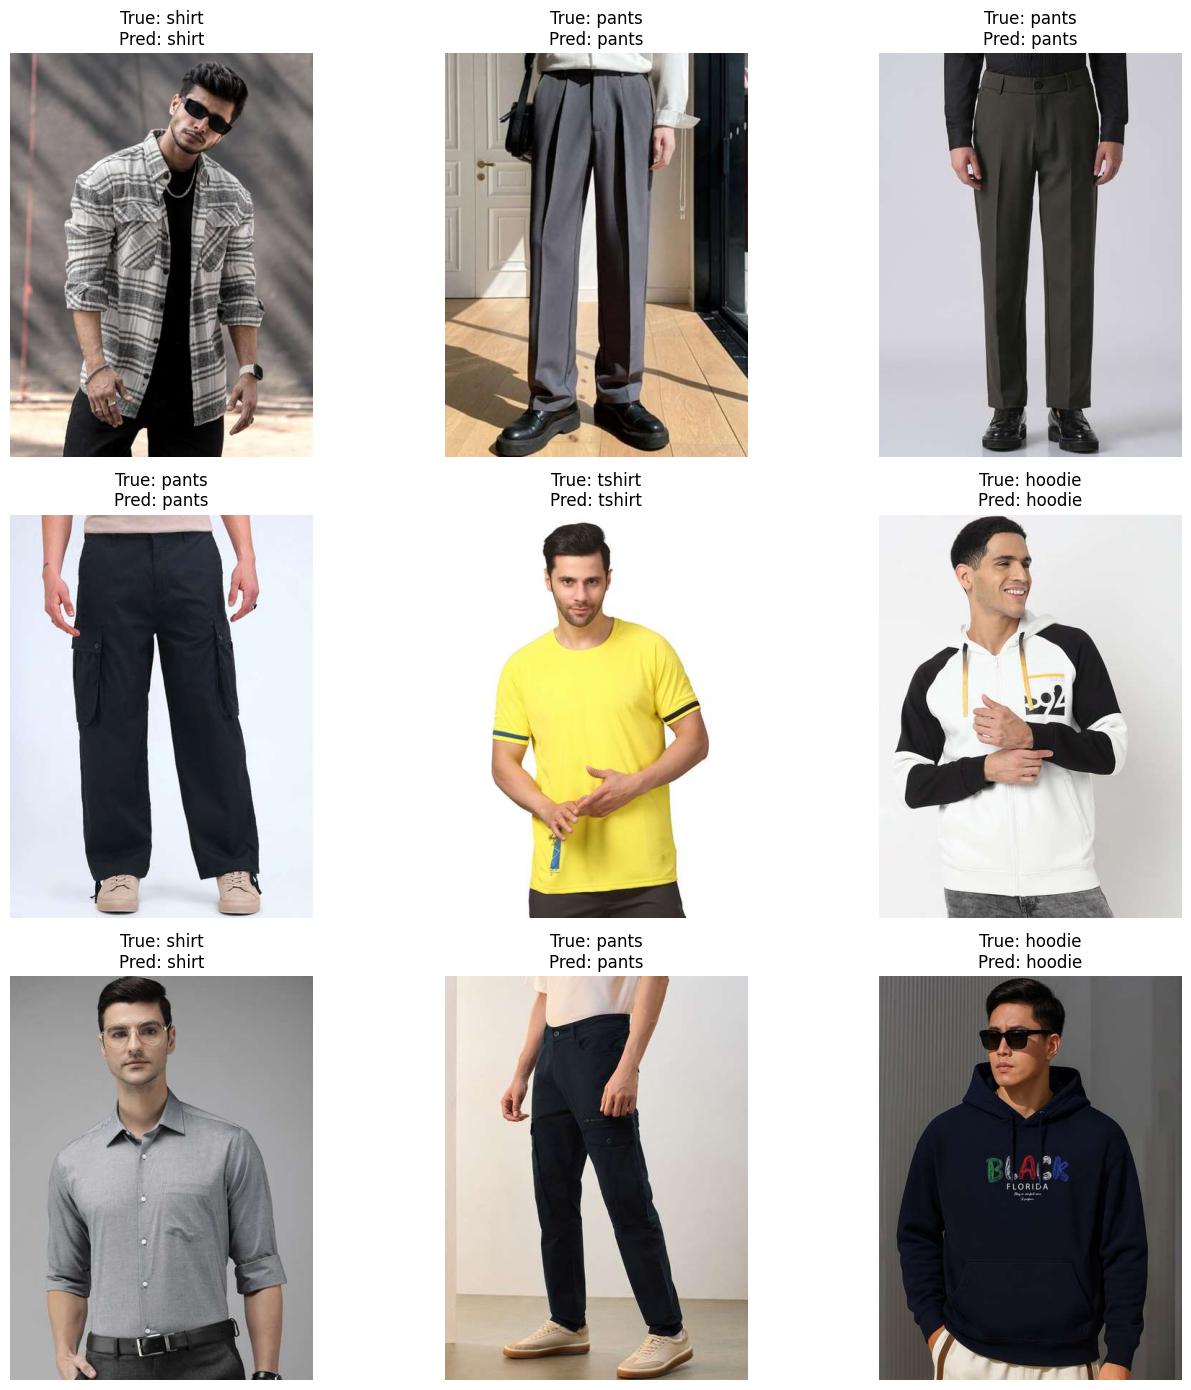

In [25]:
# =========================================================
# RANDOM TEST PREDICTIONS
# =========================================================

random_indices = random.sample(
    range(len(test_df)),
    9
)

plt.figure(figsize=(14, 14))

for i, idx in enumerate(random_indices):

    row = test_df.iloc[idx]

    image_path = row["image_path"]

    true_label = row["label"]

    image = Image.open(image_path).convert("RGB")

    image_np = np.array(image)

    transformed = test_transforms(
        image=image_np
    )

    image_tensor = transformed["image"].unsqueeze(0).to(device)

    with torch.no_grad():

        output = model(image_tensor)

        pred_idx = torch.argmax(output, dim=1).item()

    pred_label = IDX_TO_CLASS[str(pred_idx)]

    plt.subplot(3, 3, i + 1)

    plt.imshow(image)

    plt.title(
        f"True: {true_label}\nPred: {pred_label}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [26]:
# =========================================================
# FIND WRONG PREDICTIONS
# =========================================================

wrong_samples = []

for idx in range(len(test_df)):

    row = test_df.iloc[idx]

    image_path = row["image_path"]

    true_label = row["label"]

    image = Image.open(image_path).convert("RGB")

    image_np = np.array(image)

    transformed = test_transforms(
        image=image_np
    )

    image_tensor = transformed["image"].unsqueeze(0).to(device)

    with torch.no_grad():

        output = model(image_tensor)

        pred_idx = torch.argmax(output, dim=1).item()

    pred_label = IDX_TO_CLASS[str(pred_idx)]

    if pred_label != true_label:

        wrong_samples.append({

            "image": image,
            "true": true_label,
            "pred": pred_label
        })

print("❌ Total Wrong Predictions:",
      len(wrong_samples))

❌ Total Wrong Predictions: 51


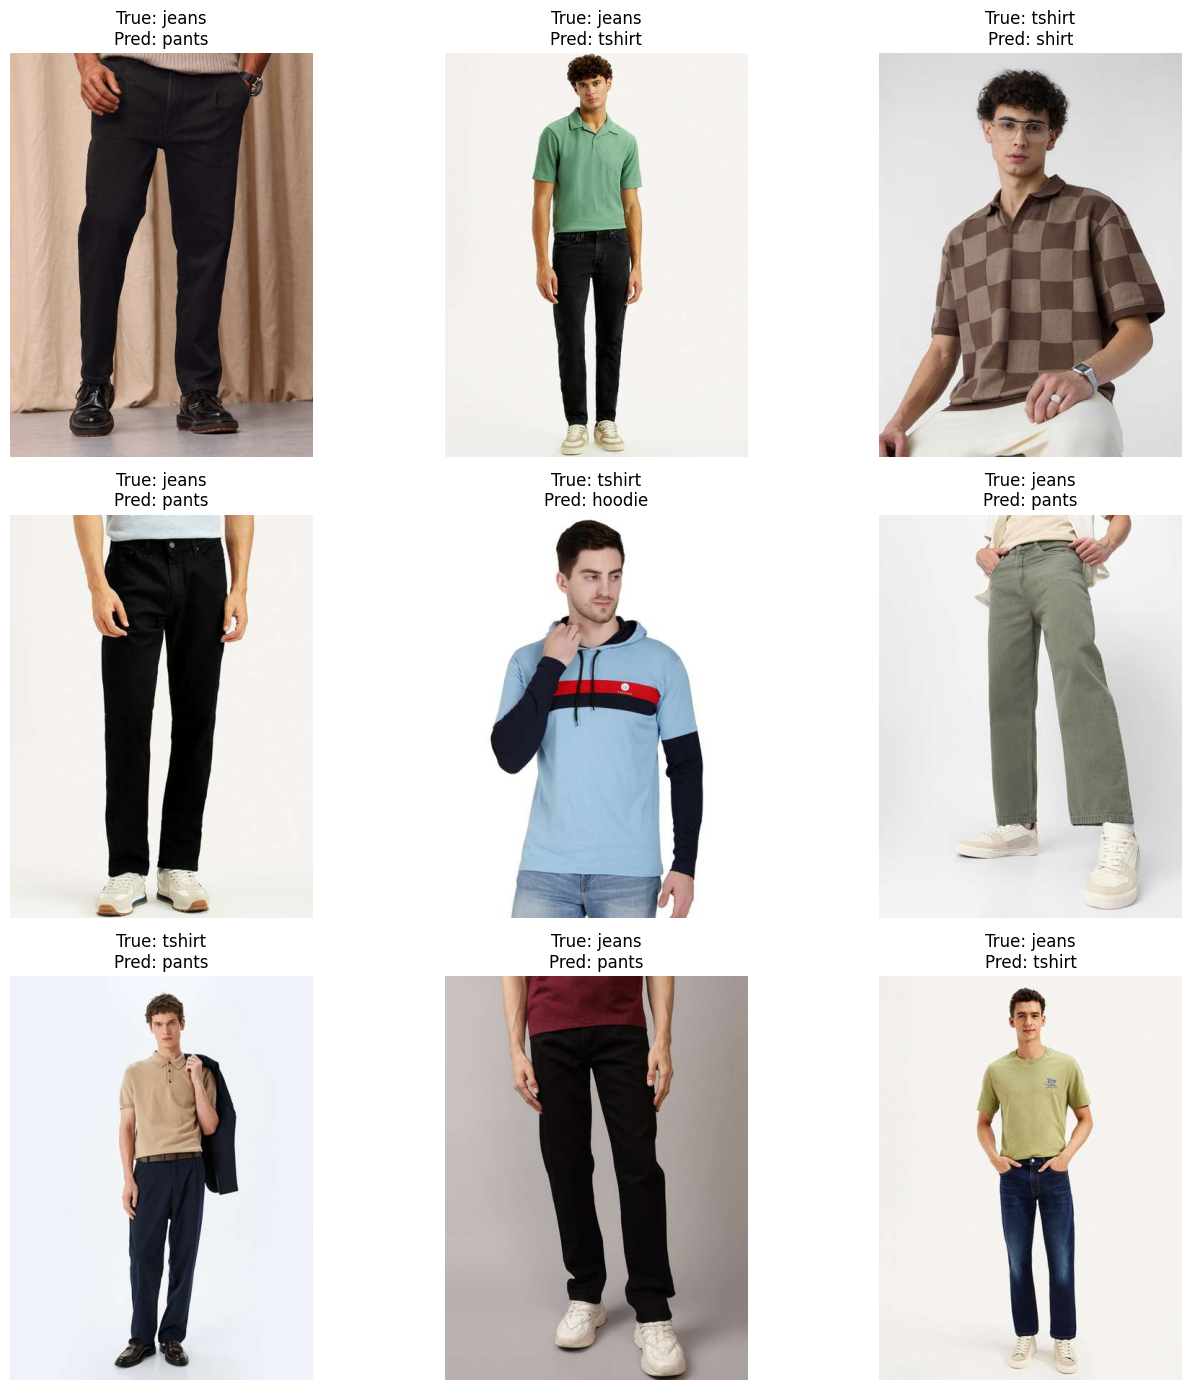

In [27]:
# =========================================================
# VISUALIZE WRONG PREDICTIONS
# =========================================================

num_samples = min(9, len(wrong_samples))

plt.figure(figsize=(14, 14))

for i in range(num_samples):

    sample = wrong_samples[i]

    plt.subplot(3, 3, i + 1)

    plt.imshow(sample["image"])

    plt.title(
        f"True: {sample['true']}\nPred: {sample['pred']}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()